#  Policy Gradients

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Саттон Р. С., Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* Лю Ю. (Х.) Обучение с подкреплением на PyTorch: сборник рецептов / пер. с англ. А. А. Слинкина. – М.: ДМК Пресс, 2020
* https://www.youtube.com/watch?v=_x0ASf9jV9U&ab_channel=sim0nsays
* https://karpathy.github.io/2016/05/31/rl/
* https://neerc.ifmo.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_policy_gradient_%D0%B8_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B0%D1%81%D0%B8%D0%BD%D1%85%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%B0-%D0%BA%D1%80%D0%B8%D1%82%D0%B8%D0%BA%D0%B0
* https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html
* https://huggingface.co/learn/deep-rl-course/unit4/introduction
* https://lilianweng.github.io/posts/2018-04-08-policy-gradient/#:~:text=The%20goal%20of%20reinforcement%20learning,and%20optimizing%20the%20policy%20directly.

## Задачи для совместного разбора

1\. Рассмотрите основные шаги по формированию обучающей выборки для использования алгоритмов Policy Gradients.

In [157]:
import torch as th

In [158]:
state_dim = 5
n_action = 3

state = th.rand(state_dim)

In [159]:
import torch.nn as nn

In [160]:
model = nn.Sequential(
    nn.Linear(state_dim, n_action),
    nn.Softmax()
)

In [161]:
prediction = model(state)

In [162]:
action = th.multinomial(prediction, 1).item()
action

2

In [163]:
log_prob = prediction[action].log()
log_prob

tensor(-1.1076, grad_fn=<LogBackward0>)

In [164]:
th.rand(1)

tensor([0.5239])

In [165]:
log_probs = []
rewards = []

state = th.rand(state_dim) # reset
for _ in range(10):
  # ... env.step()
  prediction = model(state)
  action = th.multinomial(prediction, 1).item()
  log_prob = prediction[action].log()
  r = th.rand(1)

  log_probs.append(log_prob)
  rewards.append(r.item())

In [166]:
log_probs

[tensor(-0.9722, grad_fn=<LogBackward0>),
 tensor(-0.9722, grad_fn=<LogBackward0>),
 tensor(-0.6966, grad_fn=<LogBackward0>),
 tensor(-0.9722, grad_fn=<LogBackward0>),
 tensor(-0.6966, grad_fn=<LogBackward0>),
 tensor(-2.0916, grad_fn=<LogBackward0>),
 tensor(-0.9722, grad_fn=<LogBackward0>),
 tensor(-0.6966, grad_fn=<LogBackward0>),
 tensor(-0.9722, grad_fn=<LogBackward0>),
 tensor(-0.9722, grad_fn=<LogBackward0>)]

In [167]:
rewards # r

[0.11088305711746216,
 0.40272408723831177,
 0.3564855456352234,
 0.1785123348236084,
 0.36389845609664917,
 0.13377678394317627,
 0.4835383892059326,
 0.3585846424102783,
 0.8438237905502319,
 0.11261844635009766]

In [168]:
len(rewards)

10

In [169]:
# gamma = 0.99
# R[9] = 0.1322454810142517
# R[8] = 0.7268886566162109 + gamma* 0.1322454810142517
# # ...

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Допишите классы `Policy` для реализации модели политики и `Trainer` для реализации процесса обучения модели при помощи алгоритма REINFORCE. Настройте агента для игры в окружении `CartPole-v1`. Визуализируйте динамику значений награды на эпизод в процессе обучения. Сыграйте эпизод, используя обученного агента, и убедитесь, что агент выучивается, как стабилизировать шест.

$$L_{PG} = -\sum_{i}{R_i\log{p(a_i|s_i)}}$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.


- [ ] Проверено на семинаре

In [170]:
pip install gymnasium

In [171]:
import torch
import gymnasium as gym
import torch.nn as nn

In [172]:
env = gym.make('CartPole-v1', render_mode='rgb_array')
env.observation_space, env.action_space

(Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32),
 Discrete(2))

In [173]:
# state
# позиция тележки – значение в диапазоне [-4.8, 4.8];
# скорость тележки;
# угол отклонения шеста от вертикали – значение в диапазоне [-24°, 24°];
# скорость изменения угла наклона шеста.

# action
# 0 – толкнуть тележку влево (приложить к тележке горизонтальную силу, равную +1);
# 1 – толкнуть тележку вправо (приложить к тележке горизонтальную силу, равную -1).

In [174]:
env.reset()

(array([-0.03166622,  0.02861493,  0.04109843,  0.00402995], dtype=float32),
 {})

In [175]:
from dataclasses import dataclass
@dataclass
class PolicyConfig:
    n_state: int
    n_action: int
    n_hidden: int

In [176]:
policy_config = PolicyConfig(n_state= env.observation_space.shape[0], n_action= env.action_space.n, n_hidden=48); policy_config

PolicyConfig(n_state=4, n_action=2, n_hidden=48)

In [177]:
class PolicyNetwork(nn.Module):
    def __init__(self, policy_config: PolicyConfig):
        super().__init__()
        self.cfg = policy_config
        self.model = nn.Sequential(
            nn.Linear(in_features= self.cfg.n_state, out_features= self.cfg.n_hidden),
            nn.ReLU(),
            nn.Linear(in_features =  self.cfg.n_hidden, out_features= self.cfg.n_action),
            nn.Softmax()
        )

    def forward(self, s: th.Tensor) -> th.Tensor:
        return self.model(s)

    def get_action(self, s: th.Tensor) -> tuple[int, float]:
        # возвращает действие пропорционально вероятностям, полученным при помощи модели
        prediction = self.model(s)
        action = th.multinomial(prediction, 1).item()

        # и логарифм вероятности выбранного действия
        log_prob = prediction[action].log()

        return action, log_prob

In [178]:
model = PolicyNetwork(policy_config); model

PolicyNetwork(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=2, bias=True)
    (3): Softmax(dim=None)
  )
)

In [179]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    gamma: float = 0.99
    learning_rate: float = 0.001
    episode_num: float = 400

In [180]:
import torch.optim as optim

In [181]:
class Trainer:

  def __init__(self, train_config, model):

    self.train_config =  train_config
    self.model = model

  def get_loss(self, log_probs, returns):
    return (-th.stack(log_probs) * returns).sum()

  def get_returns(self, rewards):

    returns = []
    R = 0
    for i in  rewards[::-1]:
        # print(i)
        R = i + self.train_config.gamma*R
        returns.insert(0, R)
    return th.tensor(returns)

  def train(self, rewards, log_probs):

    optimizer = optim.Adam(params = self.model.parameters(), lr = self.train_config.learning_rate)
    returns = self.get_returns(rewards)
    # print(returns)
    loss = self.get_loss(log_probs, returns)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


In [182]:
trainer = Trainer(train_config= TrainConfig(), model = model)

In [189]:
from gymnasium.wrappers import RecordVideo


env = RecordVideo(env, video_folder="/content", episode_trigger=lambda x: (x+1) % 100 == 0)

episode_rewards = []   #  награды на эпизод
for episode in range(TrainConfig().episode_num):

    state, info = env.reset()   # начальное состояние
    state = th.tensor(state)

    rewards, log_probs = [], []

    while True:

        action, log_prob = model.get_action(state)   # действие пропорционально вероятностям и логарифм вроятности выбранного действия
        state, reward, terminated, truncated, info = env.step(action)
        state = th.tensor(state)

        done = terminated or truncated
        rewards.append(reward)
        log_probs.append(log_prob)

        if done == True:

          trainer.train(rewards, log_probs)
          episode_rewards.append(sum(rewards))   # все победы за эпизод
          break

    if (episode+1) % 10 == 0 or episode == 0:
        print(f"Episode №{episode+1}, Reward = {sum(rewards)}")

/usr/local/lib/python3.10/dist-packages/gymnasium/wrappers/record_video.py:94: UserWarning: WARN: Overwriting existing videos at /content folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1518: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Episode №1, Reward = 29.0
Episode №10, Reward = 20.0
Episode №20, Reward = 17.0
Episode №30, Reward = 23.0
Episode №40, Reward = 14.0
Episode №50, Reward = 21.0
Episode №60, Reward = 19.0
Episode №70, Reward = 15.0
Episode №80, Reward = 17.0
Episode №90, Reward = 18.0
Moviepy - Building video /content/rl-video-episode-99.mp4.
Moviepy - Writing video /content/rl-video-episode-99.mp4



Moviepy - Done !
Moviepy - video ready /content/rl-video-episode-99.mp4
Episode №100, Reward = 15.0


Episode №110, Reward = 25.0
Episode №120, Reward = 18.0
Episode №130, Reward = 22.0
Episode №140, Reward = 14.0
Episode №150, Reward = 23.0
Episode №160, Reward = 25.0
Episode №170, Reward = 27.0
Episode №180, Reward = 38.0
Episode №190, Reward = 23.0
Moviepy - Building video /content/rl-video-episode-199.mp4.
Moviepy - Writing video /content/rl-video-episode-199.mp4



Moviepy - Done !
Moviepy - video ready /content/rl-video-episode-199.mp4
Episode №200, Reward = 18.0


Episode №210, Reward = 27.0
Episode №220, Reward = 29.0
Episode №230, Reward = 20.0
Episode №240, Reward = 26.0
Episode №250, Reward = 30.0
Episode №260, Reward = 28.0
Episode №270, Reward = 28.0
Episode №280, Reward = 23.0
Episode №290, Reward = 24.0
Moviepy - Building video /content/rl-video-episode-299.mp4.
Moviepy - Writing video /content/rl-video-episode-299.mp4



Moviepy - Done !
Moviepy - video ready /content/rl-video-episode-299.mp4
Episode №300, Reward = 23.0


Episode №310, Reward = 15.0
Episode №320, Reward = 21.0
Episode №330, Reward = 34.0
Episode №340, Reward = 21.0
Episode №350, Reward = 29.0
Episode №360, Reward = 22.0
Episode №370, Reward = 23.0
Episode №380, Reward = 34.0
Episode №390, Reward = 33.0
Moviepy - Building video /content/rl-video-episode-799.mp4.
Moviepy - Writing video /content/rl-video-episode-799.mp4



Moviepy - Done !
Moviepy - video ready /content/rl-video-episode-799.mp4
Moviepy - Building video /content/rl-video-episode-399.mp4.
Moviepy - Writing video /content/rl-video-episode-399.mp4



Moviepy - Done !
Moviepy - video ready /content/rl-video-episode-399.mp4
Episode №400, Reward = 21.0


Text(0, 0.5, 'Rewards')

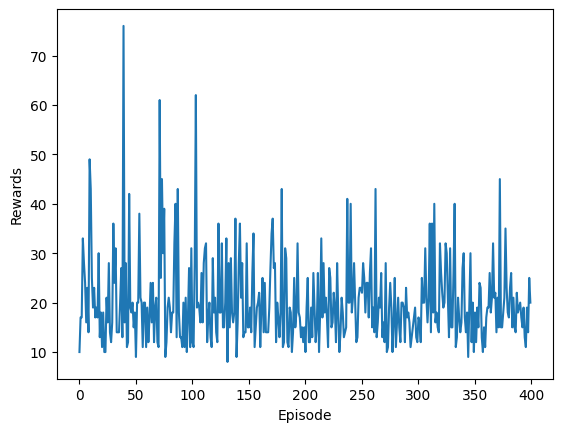

In [184]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(TrainConfig().episode_num), episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Rewards')

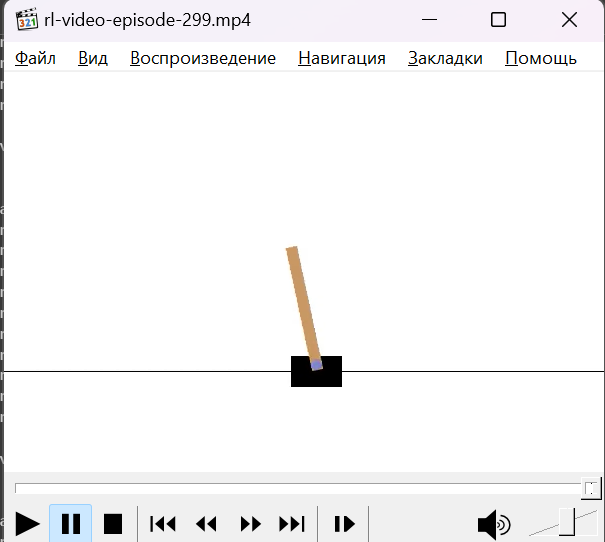

<p class="task" id="2"></p>

2\. Повторите решение задачи 1, делая шаг обучения не после одного эпизода, а по результату прогонов нескольких эпизодов. Обратите внимание, что после обновления весов модели все старые данные для обучения становятся неактуальными и должны быть удалены.

- [ ] Проверено на семинаре

In [185]:
episode_rewards = []   #  награды на эпизод
for episode in range(TrainConfig().episode_num):

    state, info = env.reset()   # начальное состояние
    state = th.tensor(state)

    rewards, log_probs = [], []  # параметры train
    total = []

    while True:

        action, log_prob = model.get_action(state)   # действие пропорционально вероятностям и логарифм вроятности выбранного действия
        state, reward, terminated, truncated, info = env.step(action)
        state = th.tensor(state)

        done = terminated or truncated
        rewards.append(reward)
        total.append(reward)
        log_probs.append(log_prob)

        if done == True:
          if episode % 50 == 0:    # обучение после прогона через 50 эпизодов
            trainer.train(rewards, log_probs)
            rewards = []  # удаление данных
            log_probs = []
          episode_rewards.append(sum(total))   # все победы за эпизод
          break

    if (episode+1) % 10 == 0 or episode == 0:
        print(f"Episode №{episode+1}, Reward = {sum(rewards)}")

Episode №1, Reward = 0
Episode №10, Reward = 13.0
Episode №20, Reward = 17.0
Episode №30, Reward = 30.0
Episode №40, Reward = 30.0
Episode №50, Reward = 20.0
Episode №60, Reward = 13.0
Episode №70, Reward = 12.0
Episode №80, Reward = 15.0
Episode №90, Reward = 14.0
Episode №100, Reward = 16.0
Episode №110, Reward = 12.0
Episode №120, Reward = 16.0
Episode №130, Reward = 21.0
Episode №140, Reward = 17.0
Episode №150, Reward = 14.0
Episode №160, Reward = 22.0
Episode №170, Reward = 16.0
Episode №180, Reward = 16.0
Episode №190, Reward = 20.0
Episode №200, Reward = 19.0
Episode №210, Reward = 15.0
Episode №220, Reward = 19.0
Episode №230, Reward = 19.0
Episode №240, Reward = 12.0
Episode №250, Reward = 22.0
Episode №260, Reward = 19.0
Episode №270, Reward = 16.0
Episode №280, Reward = 25.0
Episode №290, Reward = 14.0
Episode №300, Reward = 15.0
Episode №310, Reward = 20.0
Episode №320, Reward = 22.0
Episode №330, Reward = 10.0
Episode №340, Reward = 16.0
Episode №350, Reward = 13.0
Episod

In [186]:
len(episode_rewards)

400

Text(0, 0.5, 'Rewards')

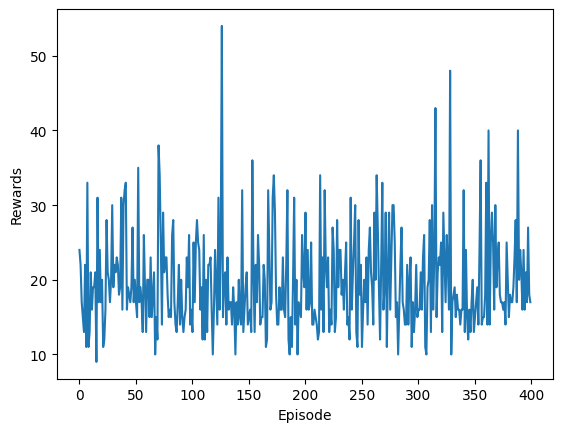

In [187]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.arange(TrainConfig().episode_num), episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Rewards')

<p class="task" id="3"></p>

3\. Повторите решение задачи 1, реализовав алгоритм REINFONCE с baseline.

$$L_{PG} = -\sum_{i}{A_i\log{p(a_i|s_i)}}$$

$$A_i = R_i - V(s_i)$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.

$p(a_i|s_i)$ и $V(s_i)$ моделируются при помощи двух независимых сетей. Сеть для политики настраивается аналогично задаче 1 и 2 при помощи функции потерь $L_{PG}$. Сеть для оценки базы настраивается в процессе решения задачи регрессии: $L_{V} = \sum_i(V(s_i) - R_i)^2$. Настройка весов обеих моделей происходит после каждого эпизода.

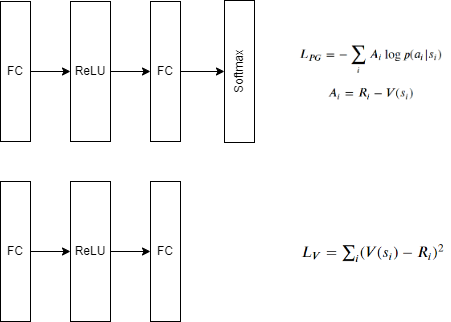

- [ ] Проверено на семинаре

<p class="task" id="4"></p>

4\. Повторите решение задачи 1, реализовав алгоритм Actor-Critic

$$L_{PG} = -\sum_{i}{A_i\log{p(a_i|s_i)}}$$

$$A_i = R_i - V(s_i)$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.

$p(a_i|s_i)$ и $V(s_i)$ моделируются при помощи одной сети в двумя головами. Голова для политики настраивается аналогично задаче 1 и 2 при помощи функции потерь $L_{PG}$. Голова для оценки базы настраивается в процессе решения задачи регрессии: $L_{V} = \sum_i(V(s_i) - R_i)^2$. Итоговая функции потерь для настройки представляет из себя сумму функций потерь для голов: $L = L_{PG} + L_{V}$.

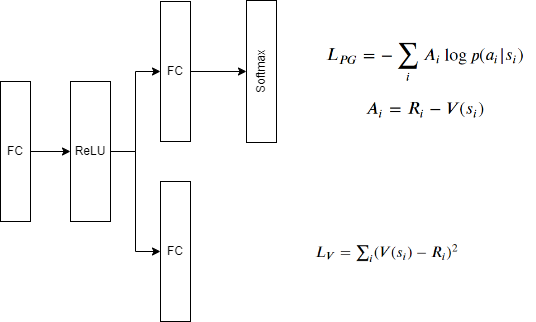

- [ ] Проверено на семинаре

## Обратная связь
- [ ] Хочу получить обратную связь по решению